In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as quan

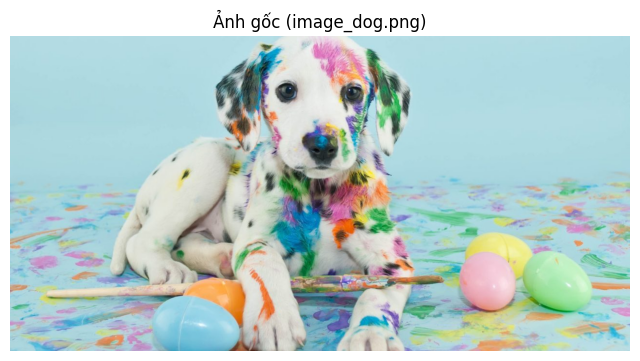

In [ ]:
# Đọc ảnh 
img = cv.imread('image_dog.png')
if img is None:
    raise FileNotFoundError("Không tìm thấy file image_dog.png")

gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Hiển thị ảnh gốc
quan.figure(figsize=(8,6))
quan.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
quan.title('Ảnh gốc (image_dog.png)')
quan.axis('off')
quan.show()

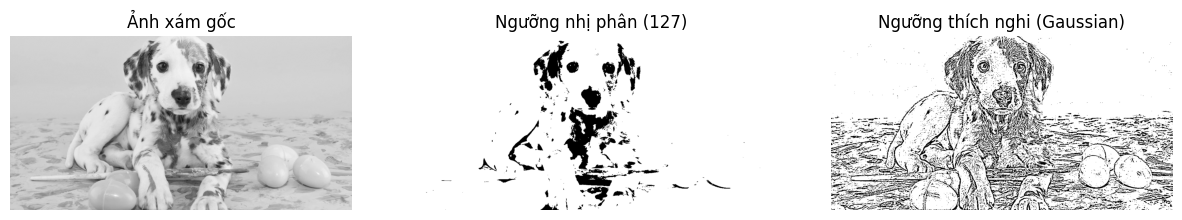

In [6]:
# Ngưỡng nhị phân đơn giản: pixel > 127 -> 255, ngược lại -> 0
ret, thresh_binary = cv.threshold(gray, 127, 255, cv.THRESH_BINARY)

# Ngưỡng thích nghi (adaptive threshold): tính ngưỡng cục bộ dựa trên vùng lân cận
# Tham số: 11 là kích thước vùng lân cận, 2 là hằng số trừ đi
thresh_adapt = cv.adaptiveThreshold(gray, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C,
                                    cv.THRESH_BINARY, 11, 2)

# Hiển thị kết quả so sánh
quan.figure(figsize=(15,5))
quan.subplot(1,3,1)
quan.imshow(gray, cmap='gray')
quan.title('Ảnh xám gốc')
quan.axis('off')

quan.subplot(1,3,2)
quan.imshow(thresh_binary, cmap='gray')
quan.title('Ngưỡng nhị phân (127)')
quan.axis('off')

quan.subplot(1,3,3)
quan.imshow(thresh_adapt, cmap='gray')
quan.title('Ngưỡng thích nghi (Gaussian)')
quan.axis('off')
quan.show()

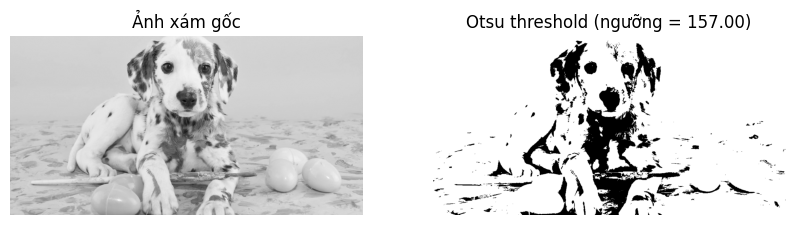

In [7]:
# Otsu: tự động tính ngưỡng dựa trên histogram, tối ưu phương sai giữa các lớp
# Tham số 0 và THRESH_OTSU báo hiệu dùng Otsu
ret_otsu, thresh_otsu = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

quan.figure(figsize=(10,5))
quan.subplot(1,2,1)
quan.imshow(gray, cmap='gray')
quan.title('Ảnh xám gốc')
quan.axis('off')

quan.subplot(1,2,2)
quan.imshow(thresh_otsu, cmap='gray')
quan.title(f'Otsu threshold (ngưỡng = {ret_otsu:.2f})')
quan.axis('off')
quan.show()

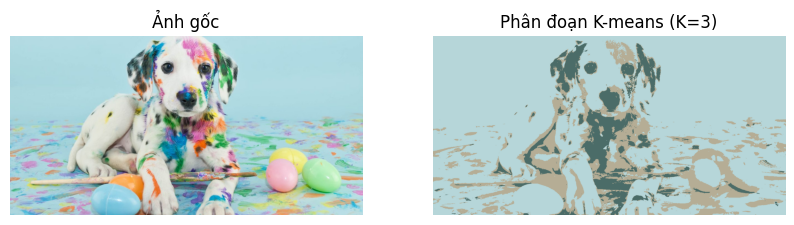

In [8]:
# Chuyển ảnh thành mảng 1 chiều các điểm ảnh RGB (mỗi điểm là vector 3 chiều)
data = img.reshape((-1, 3))
data = np.float32(data)   # K-means yêu cầu dữ liệu float32

# Tham số K-means: K=3 cụm, lặp tối đa 10 lần, tiêu chuẩn dừng = 1.0
K = 3
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)
_, labels, centers = cv.kmeans(data, K, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

# Gán lại màu cho mỗi điểm ảnh theo cụm
centers = np.uint8(centers)
segmented_data = centers[labels.flatten()]
segmented_img = segmented_data.reshape(img.shape)

# Hiển thị ảnh gốc và ảnh phân đoạn bằng K-means
quan.figure(figsize=(10,5))
quan.subplot(1,2,1)
quan.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
quan.title('Ảnh gốc')
quan.axis('off')

quan.subplot(1,2,2)
quan.imshow(cv.cvtColor(segmented_img, cv.COLOR_BGR2RGB))
quan.title(f'Phân đoạn K-means (K={K})')
quan.axis('off')
quan.show()

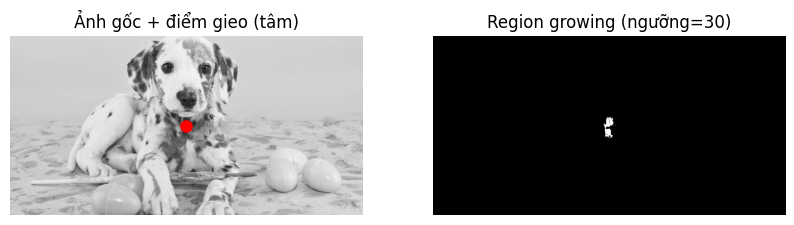

In [9]:
# Định nghĩa hàm region growing
def region_growing(img_gray, seed, threshold):
    """
    img_gray: ảnh grayscale
    seed: (x,y) điểm bắt đầu
    threshold: ngưỡng sai khác cường độ sáng cho phép
    """
    h, w = img_gray.shape
    segmented = np.zeros_like(img_gray, dtype=np.uint8)  # ảnh kết quả
    visited = np.zeros_like(img_gray, dtype=bool)        # đánh dấu đã xét
    stack = [seed]
    visited[seed[1], seed[0]] = True
    seed_val = img_gray[seed[1], seed[0]]                # giá trị cường độ tại seed

    while stack:
        x, y = stack.pop()
        segmented[y, x] = 255                            # tô trắng vùng được chọn
        # Xét 8 lân cận (kể cả chéo)
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                if dx == 0 and dy == 0:
                    continue
                nx, ny = x + dx, y + dy
                if 0 <= nx < w and 0 <= ny < h and not visited[ny, nx]:
                    # Nếu chênh lệch cường độ <= threshold thì thêm vào vùng
                    if abs(int(img_gray[ny, nx]) - int(seed_val)) <= threshold:
                        visited[ny, nx] = True
                        stack.append((nx, ny))
    return segmented

# Chọn seed là tâm của ảnh
h, w = gray.shape
seed_point = (w // 2, h // 2)
threshold_val = 30   # ngưỡng càng lớn thì vùng càng rộng

region_result = region_growing(gray, seed_point, threshold_val)

quan.figure(figsize=(10,5))
quan.subplot(1,2,1)
quan.imshow(gray, cmap='gray')
quan.plot(seed_point[0], seed_point[1], 'ro', markersize=8)  # chấm đỏ tại seed
quan.title('Ảnh gốc + điểm gieo (tâm)')
quan.axis('off')

quan.subplot(1,2,2)
quan.imshow(region_result, cmap='gray')
quan.title(f'Region growing (ngưỡng={threshold_val})')
quan.axis('off')
quan.show()

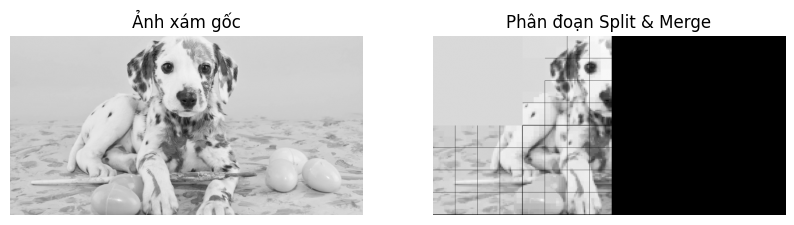

In [10]:
# Hàm kiểm tra tính đồng nhất của một vùng (dựa trên phương sai)
def is_homogeneous(region, threshold=30):
    return np.var(region) < threshold

# Hàm chia (split) đệ quy: chia block thành 4 nếu không đồng nhất
def split_quad(image, x, y, size, threshold, result):
    if size < 8:   # kích thước block tối thiểu, dừng chia
        result[y:y+size, x:x+size] = np.mean(image[y:y+size, x:x+size])
        return
    sub = image[y:y+size, x:x+size]
    if is_homogeneous(sub, threshold):
        # Nếu đồng nhất, gán giá trị trung bình cho toàn block
        result[y:y+size, x:x+size] = np.mean(sub)
    else:
        # Chia làm 4
        half = size // 2
        split_quad(image, x, y, half, threshold, result)
        split_quad(image, x+half, y, half, threshold, result)
        split_quad(image, x, y+half, half, threshold, result)
        split_quad(image, x+half, y+half, half, threshold, result)

# Hàm split-merge tổng thể
def split_merge(image, threshold=30):
    h, w = image.shape
    result = np.zeros_like(image, dtype=np.float32)
    split_quad(image, 0, 0, min(h, w), threshold, result)
    return np.uint8(result)

# Áp dụng lên ảnh xám (ngưỡng đồng nhất = 40)
split_merge_result = split_merge(gray, threshold=40)

quan.figure(figsize=(10,5))
quan.subplot(1,2,1)
quan.imshow(gray, cmap='gray')
quan.title('Ảnh xám gốc')
quan.axis('off')

quan.subplot(1,2,2)
quan.imshow(split_merge_result, cmap='gray')
quan.title('Phân đoạn Split & Merge')
quan.axis('off')
quan.show()

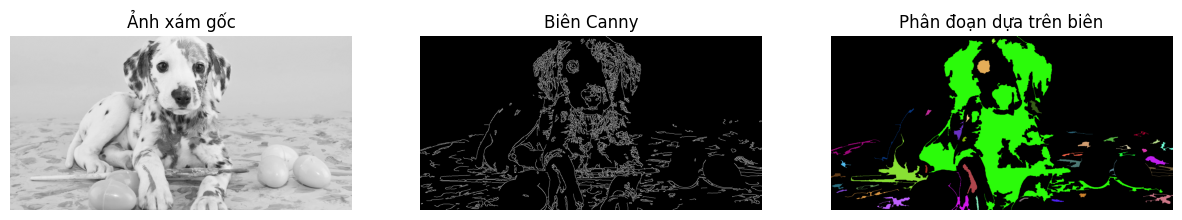

In [11]:
# Dùng bộ lọc Canny để phát hiện biên (ngưỡng dưới 50, ngưỡng trên 150)
edges = cv.Canny(gray, 50, 150)

# Đóng các lỗ hổng trên biên bằng phép toán morphology (dilate + erode)
kernel = np.ones((3,3), np.uint8)
edges_closed = cv.morphologyEx(edges, cv.MORPH_CLOSE, kernel, iterations=2)

# Tìm các đường viền (contour) từ ảnh biên đã đóng
contours, _ = cv.findContours(edges_closed, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

# Tạo ảnh kết quả, tô màu ngẫu nhiên từng vùng
segmented_edge = np.zeros_like(img)
for cnt in contours:
    if cv.contourArea(cnt) > 100:   # Bỏ qua các vùng quá nhỏ (nhiễu)
        color = np.random.randint(0, 255, 3).tolist()  # màu ngẫu nhiên
        cv.drawContours(segmented_edge, [cnt], -1, color, thickness=cv.FILLED)

# Hiển thị ảnh gốc, ảnh biên Canny, và kết quả phân đoạn
quan.figure(figsize=(15,5))
quan.subplot(1,3,1)
quan.imshow(gray, cmap='gray')
quan.title('Ảnh xám gốc')
quan.axis('off')

quan.subplot(1,3,2)
quan.imshow(edges, cmap='gray')
quan.title('Biên Canny')
quan.axis('off')

quan.subplot(1,3,3)
quan.imshow(cv.cvtColor(segmented_edge, cv.COLOR_BGR2RGB))
quan.title('Phân đoạn dựa trên biên')
quan.axis('off')
quan.show()